# Semiconductor Manufacturing Yield Prediction



This project focuses on predicting the Pass/Fail yield of semiconductor manufacturing entities using sensor measurements. The analysis will investigate data cleaning, exploratory data analysis, feature selection, dimensionality reduction, class imbalance, and multiple machine learning models.

The objective is to determine whether all sensor features are required for effective yield prediction and to identify the best-performing classification model.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Data Loading

The SECOM dataset contains sensor measurements collected during the semiconductor manufacturing process. The `secom.data` file contains 591 sensor features for each production entity.

In [3]:
sensor_df = pd.read_csv(
    "secom.data",
    sep=r"\s+",
    header=None
)

print("Sensor data loaded successfully.")
print("Dataset shape:", sensor_df.shape)

sensor_df.head()

Sensor data loaded successfully.
Dataset shape: (1567, 590)


,0,1,2,3,4,5,6,7,8,9,...,580,581,582,583,584,585,586,587,588,589
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,NaN,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,0.0060,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,0.0148,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,...,0.0044,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,...,NaN,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432


## 2. Loading Pass/Fail Labels

The `secom_labels.data` file contains the Pass/Fail yield label and the timestamp associated with each production entity.

- `-1` represents Pass
- `1` represents Fail

In [4]:
labels_df = pd.read_csv(
    "secom_labels.data",
    sep=r"\s+",
    header=None
)

print("Labels data loaded successfully.")
print("Dataset shape:", labels_df.shape)

labels_df.head()

Labels data loaded successfully.
Dataset shape: (1567, 2)


,0,1
0,-1,19/07/2008 11:55:00
1,-1,19/07/2008 12:32:00
2,1,19/07/2008 13:17:00
3,-1,19/07/2008 14:43:00
4,-1,19/07/2008 15:22:00


## 3. Preparing the Dataset

The sensor dataset contains 591 measurement features, while the labels dataset contains the Pass/Fail target and timestamp information.

For this project, the sensor features and the target variable will be combined into a single dataset for further analysis and machine learning.

In [5]:
sensor_columns = [f"Sensor_{i}" for i in range(1, 591)]

# Assign column names
sensor_df.columns = sensor_columns

# Name the label columns
labels_df.columns = ["Target", "Timestamp"]

print("Sensor data:")
display(sensor_df.head())

print("Labels data:")
display(labels_df.head())

Sensor data:


,Sensor_1,Sensor_2,Sensor_3,Sensor_4,Sensor_5,Sensor_6,Sensor_7,Sensor_8,Sensor_9,Sensor_10,...,Sensor_581,Sensor_582,Sensor_583,Sensor_584,Sensor_585,Sensor_586,Sensor_587,Sensor_588,Sensor_589,Sensor_590
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,NaN,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,0.0060,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,0.0148,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,...,0.0044,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,...,NaN,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432


Labels data:


,Target,Timestamp
0,-1,19/07/2008 11:55:00
1,-1,19/07/2008 12:32:00
2,1,19/07/2008 13:17:00
3,-1,19/07/2008 14:43:00
4,-1,19/07/2008 15:22:00


In [6]:
print("Sensor shape:", sensor_df.shape)
print("Number of sensor columns:", len(sensor_df.columns))

print("\nFirst 5 sensor columns:")
print(sensor_df.columns[:5])

print("\nLast 5 sensor columns:")
print(sensor_df.columns[-5:])

Sensor shape: (1567, 590)
Number of sensor columns: 590

First 5 sensor columns:
Index(['Sensor_1', 'Sensor_2', 'Sensor_3', 'Sensor_4', 'Sensor_5'], dtype='object')

Last 5 sensor columns:
Index(['Sensor_586', 'Sensor_587', 'Sensor_588', 'Sensor_589', 'Sensor_590'], dtype='object')


In [7]:
# Combine sensor features with the target column

df = pd.concat(
    [sensor_df, labels_df["Target"]],
    axis=1
)

print("Final dataset shape:", df.shape)

df.head()

Final dataset shape: (1567, 591)


,Sensor_1,Sensor_2,Sensor_3,Sensor_4,Sensor_5,Sensor_6,Sensor_7,Sensor_8,Sensor_9,Sensor_10,...,Sensor_582,Sensor_583,Sensor_584,Sensor_585,Sensor_586,Sensor_587,Sensor_588,Sensor_589,Sensor_590,Target
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,...,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1


## 4. Creating the Final Dataset

The sensor measurement features and the Pass/Fail target variable are combined into a single dataset. The final dataset is saved as `sensor-data.csv` for further analysis and machine learning.

In [8]:
# Save the combined dataset as a CSV file

df.to_csv("sensor-data.csv", index=False)

print("sensor-data.csv created successfully.")
print("Final dataset shape:", df.shape)

sensor-data.csv created successfully.
Final dataset shape: (1567, 591)


In [ ]:
df.head()

,Sensor_1,Sensor_2,Sensor_3,Sensor_4,Sensor_5,Sensor_6,Sensor_7,Sensor_8,Sensor_9,Sensor_10,...,Sensor_582,Sensor_583,Sensor_584,Sensor_585,Sensor_586,Sensor_587,Sensor_588,Sensor_589,Sensor_590,Target
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,...,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1


# Phase 1: Data Import and Exploration

In this phase, the prepared semiconductor sensor dataset is imported and explored to understand its structure, dimensions, data types, and basic statistical characteristics before performing data cleaning and further analysis.

## 1. Loading the Dataset

The prepared `sensor-data.csv` file contains semiconductor sensor measurements and the Pass/Fail target variable.

In [10]:
df = pd.read_csv("sensor-data.csv")

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

Dataset loaded successfully.
Dataset shape: (1567, 591)


## 2. Viewing the Dataset

The first few rows of the dataset are displayed to understand the structure and values of the sensor measurements and the Target variable.

In [11]:
df.head()

,Sensor_1,Sensor_2,Sensor_3,Sensor_4,Sensor_5,Sensor_6,Sensor_7,Sensor_8,Sensor_9,Sensor_10,...,Sensor_582,Sensor_583,Sensor_584,Sensor_585,Sensor_586,Sensor_587,Sensor_588,Sensor_589,Sensor_590,Target
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,...,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1


In [12]:
df.tail()

,Sensor_1,Sensor_2,Sensor_3,Sensor_4,Sensor_5,Sensor_6,Sensor_7,Sensor_8,Sensor_9,Sensor_10,...,Sensor_582,Sensor_583,Sensor_584,Sensor_585,Sensor_586,Sensor_587,Sensor_588,Sensor_589,Sensor_590,Target
1562,2899.41,2464.36,2179.7333,3085.3781,1.4843,100.0,82.2467,0.1248,1.3424,-0.0045,...,203.1720,0.4988,0.0143,0.0039,2.8669,0.0068,0.0138,0.0047,203.1720,-1
1563,3052.31,2522.55,2198.5667,1124.6595,0.8763,100.0,98.4689,0.1205,1.4333,-0.0061,...,NaN,0.4975,0.0131,0.0036,2.6238,0.0068,0.0138,0.0047,203.1720,-1
1564,2978.81,2379.78,2206.3000,1110.4967,0.8236,100.0,99.4122,0.1208,NaN,NaN,...,43.5231,0.4987,0.0153,0.0041,3.0590,0.0197,0.0086,0.0025,43.5231,-1
1565,2894.92,2532.01,2177.0333,1183.7287,1.5726,100.0,98.7978,0.1213,1.4622,-0.0072,...,93.4941,0.5004,0.0178,0.0038,3.5662,0.0262,0.0245,0.0075,93.4941,-1
1566,2944.92,2450.76,2195.4444,2914.1792,1.5978,100.0,85.1011,0.1235,NaN,NaN,...,137.7844,0.4987,0.0181,0.0040,3.6275,0.0117,0.0162,0.0045,137.7844,-1


## 3. Dataset Information

The dataset information is examined to understand the number of entries, columns, data types, and non-null values present in the dataset.

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1567 entries, 0 to 1566
Columns: 591 entries, Sensor_1 to Target
dtypes: float64(590), int64(1)
memory usage: 7.1 MB


### Observation

The dataset contains 1567 observations and 591 columns. Among these columns, 590 columns contain numerical sensor measurements with the `float64` data type, while the `Target` column has the `int64` data type.

This confirms that the dataset consists primarily of numerical sensor features and one target variable, making it suitable for a machine learning classification problem.

## 4. Examining Column Names

The column names are examined to understand how the sensor features and target variable are organized in the dataset.

In [14]:
print("First 10 columns:")
print(df.columns[:10])

print("\nLast 10 columns:")
print(df.columns[-10:])

print("\nTotal number of columns:", len(df.columns))

First 10 columns:
Index(['Sensor_1', 'Sensor_2', 'Sensor_3', 'Sensor_4', 'Sensor_5', 'Sensor_6',
       'Sensor_7', 'Sensor_8', 'Sensor_9', 'Sensor_10'],
      dtype='object')

Last 10 columns:
Index(['Sensor_582', 'Sensor_583', 'Sensor_584', 'Sensor_585', 'Sensor_586',
       'Sensor_587', 'Sensor_588', 'Sensor_589', 'Sensor_590', 'Target'],
      dtype='object')

Total number of columns: 591


### Observation

The dataset contains 590 sensor measurement features named from `Sensor_1` to `Sensor_590`. The final column is `Target`, which represents the Pass/Fail yield outcome.

Therefore, the sensor columns will be used as predictor variables, while the `Target` column will be used as the output variable for the machine learning classification task.

## 5. Basic Statistical Summary

Descriptive statistics are calculated to obtain an initial understanding of the numerical sensor measurements, including their count, mean, standard deviation, minimum, maximum, and quartile values.

In [15]:
df.describe()

,Sensor_1,Sensor_2,Sensor_3,Sensor_4,Sensor_5,Sensor_6,Sensor_7,Sensor_8,Sensor_9,Sensor_10,...,Sensor_582,Sensor_583,Sensor_584,Sensor_585,Sensor_586,Sensor_587,Sensor_588,Sensor_589,Sensor_590,Target
count,1561.000000,1560.000000,1553.000000,1553.000000,1553.000000,1553.0,1553.000000,1558.000000,1565.000000,1565.000000,...,618.000000,1566.000000,1566.000000,1566.000000,1566.000000,1566.000000,1566.000000,1566.000000,1566.000000,1567.000000
mean,3014.452896,2495.850231,2200.547318,1396.376627,4.197013,100.0,101.112908,0.121822,1.462862,-0.000841,...,97.934373,0.500096,0.015318,0.003847,3.067826,0.021458,0.016475,0.005283,99.670066,-0.867262
std,73.621787,80.407705,29.513152,441.691640,56.355540,0.0,6.237214,0.008961,0.073897,0.015116,...,87.520966,0.003404,0.017180,0.003720,3.578033,0.012358,0.008808,0.002867,93.891919,0.498010
min,2743.240000,2158.750000,2060.660000,0.000000,0.681500,100.0,82.131100,0.000000,1.191000,-0.053400,...,0.000000,0.477800,0.006000,0.001700,1.197500,-0.016900,0.003200,0.001000,0.000000,-1.000000
25%,2966.260000,2452.247500,2181.044400,1081.875800,1.017700,100.0,97.920000,0.121100,1.411200,-0.010800,...,46.184900,0.497900,0.011600,0.003100,2.306500,0.013425,0.010600,0.003300,44.368600,-1.000000
50%,3011.490000,2499.405000,2201.066700,1285.214400,1.316800,100.0,101.512200,0.122400,1.461600,-0.001300,...,72.288900,0.500200,0.013800,0.003600,2.757650,0.020500,0.014800,0.004600,71.900500,-1.000000
75%,3056.650000,2538.822500,2218.055500,1591.223500,1.525700,100.0,104.586700,0.123800,1.516900,0.008400,...,116.539150,0.502375,0.016500,0.004100,3.295175,0.027600,0.020300,0.006400,114.749700,-1.000000
max,3356.350000,2846.440000,2315.266700,3715.041700,1114.536600,100.0,129.252200,0.128600,1.656400,0.074900,...,737.304800,0.509800,0.476600,0.104500,99.303200,0.102800,0.079900,0.028600,737.304800,1.000000


## 6. Examining the Target Variable

The Target variable represents the Pass/Fail yield outcome. The unique values and their frequency are examined to understand the distribution of the target classes.

In [16]:
print("Unique Target values:")
print(df["Target"].unique())

print("\nTarget value counts:")
print(df["Target"].value_counts())

Unique Target values:
[-1  1]

Target value counts:
Target
-1    1463
 1     104
Name: count, dtype: int64


### Observation

The Target variable contains two classes: `-1` and `1`.

The dataset contains 1463 observations with the `-1` class and only 104 observations with the `1` class. This shows that the dataset has a highly imbalanced target distribution.

The class imbalance will need to be addressed during the data preprocessing stage. Techniques such as SMOTE can be considered after performing the train-test split.

# Phase 2: Data Cleaning

## 1. Missing Value Analysis

Missing values can affect statistical analysis and machine learning model performance. Therefore, the dataset is examined to identify the number of missing values present in each sensor feature.

In [17]:
# Calculate the total missing values in the dataset

total_missing = df.isnull().sum().sum()

print("Total missing values in the dataset:", total_missing)

Total missing values in the dataset: 41951


In [18]:
# Calculate missing values in each column

missing_values = df.isnull().sum()

# Keep only columns that contain missing values
missing_columns = missing_values[missing_values > 0]

print("Number of columns containing missing values:", len(missing_columns))

print("\nTop 10 columns with the highest missing values:")
print(missing_columns.sort_values(ascending=False).head(10))

Number of columns containing missing values: 538

Top 10 columns with the highest missing values:
Sensor_293    1429
Sensor_158    1429
Sensor_159    1429
Sensor_294    1429
Sensor_493    1341
Sensor_221    1341
Sensor_359    1341
Sensor_86     1341
Sensor_517    1018
Sensor_518    1018
dtype: int64


### Observation

The dataset contains 41,951 missing values distributed across 538 sensor features. Some sensor features contain a very high number of missing values, indicating that missing-value treatment is necessary before building machine learning models.

The percentage of missing values in each feature will be calculated next to determine which features should be removed and which features can be retained and imputed.

In [19]:
# Calculate the percentage of missing values in each column

missing_percentage = (df.isnull().sum() / len(df)) * 100

# Display the top 10 columns with the highest missing percentage
print(
    missing_percentage[missing_percentage > 0]
    .sort_values(ascending=False)
    .head(10)
)

Sensor_293    91.193363
Sensor_158    91.193363
Sensor_159    91.193363
Sensor_294    91.193363
Sensor_493    85.577537
Sensor_221    85.577537
Sensor_359    85.577537
Sensor_86     85.577537
Sensor_517    64.964901
Sensor_518    64.964901
dtype: float64


## 2. Removing Features with Excessive Missing Values

Sensor features containing more than 50% missing values are removed because a large proportion of missing observations can make reliable imputation difficult and may reduce the usefulness of the feature.

The remaining features will be retained for further missing-value treatment.

In [21]:
# Identify columns with more than 50% missing values

columns_to_drop = missing_percentage[missing_percentage > 50].index

print("Number of columns with more than 50% missing values:", len(columns_to_drop))

print("\nColumns to be removed:")
print(list(columns_to_drop))

Number of columns with more than 50% missing values: 28

Columns to be removed:
['Sensor_73', 'Sensor_74', 'Sensor_86', 'Sensor_110', 'Sensor_111', 'Sensor_112', 'Sensor_158', 'Sensor_159', 'Sensor_221', 'Sensor_245', 'Sensor_246', 'Sensor_247', 'Sensor_293', 'Sensor_294', 'Sensor_346', 'Sensor_347', 'Sensor_359', 'Sensor_383', 'Sensor_384', 'Sensor_385', 'Sensor_493', 'Sensor_517', 'Sensor_518', 'Sensor_519', 'Sensor_579', 'Sensor_580', 'Sensor_581', 'Sensor_582']


In [22]:
# Remove columns with more than 50% missing values

df_cleaned = df.drop(columns=columns_to_drop)

print("Original dataset shape:", df.shape)
print("Dataset shape after removing high-missing columns:", df_cleaned.shape)

Original dataset shape: (1567, 591)
Dataset shape after removing high-missing columns: (1567, 563)


In [23]:
# Check remaining missing values after removing high-missing columns

remaining_missing = df_cleaned.isnull().sum().sum()

print("Remaining missing values:", remaining_missing)

Remaining missing values: 11683


## 3. Missing Value Imputation

After removing features with more than 50% missing values, some missing values still remain in the dataset.

The remaining missing values will be replaced using the median value of each sensor feature. Median imputation is suitable because it is less affected by extreme values compared with mean imputation.

In [24]:
# Separate sensor features and target

X_cleaned = df_cleaned.drop(columns=["Target"])
y = df_cleaned["Target"]

# Fill missing values using the median of each sensor column

X_cleaned = X_cleaned.fillna(X_cleaned.median())

# Combine features and target again

df_cleaned = pd.concat([X_cleaned, y], axis=1)

print("Remaining missing values:", df_cleaned.isnull().sum().sum())

Remaining missing values: 0


## 4. Duplicate Value Analysis

Duplicate records can negatively affect data analysis and machine learning model training. Therefore, the dataset is checked to determine whether any duplicate rows are present.

In [25]:
# Check the number of duplicate rows

duplicate_rows = df_cleaned.duplicated().sum()

print("Number of duplicate rows:", duplicate_rows)

Number of duplicate rows: 0


### Observation

The duplicate value analysis shows that the dataset contains no duplicate rows. Therefore, no duplicate records need to be removed from the dataset.

## 5. Constant Feature Analysis

Features with only one unique value do not provide useful information for machine learning classification. Therefore, the dataset is checked to identify any constant sensor features.

In [26]:
# Identify columns with only one unique value

constant_columns = [
    column for column in X_cleaned.columns
    if X_cleaned[column].nunique() <= 1
]

print("Number of constant columns:", len(constant_columns))
print("\nConstant columns:")
print(constant_columns)

Number of constant columns: 116

Constant columns:
['Sensor_6', 'Sensor_14', 'Sensor_43', 'Sensor_50', 'Sensor_53', 'Sensor_70', 'Sensor_98', 'Sensor_142', 'Sensor_150', 'Sensor_179', 'Sensor_180', 'Sensor_187', 'Sensor_190', 'Sensor_191', 'Sensor_192', 'Sensor_193', 'Sensor_194', 'Sensor_195', 'Sensor_227', 'Sensor_230', 'Sensor_231', 'Sensor_232', 'Sensor_233', 'Sensor_234', 'Sensor_235', 'Sensor_236', 'Sensor_237', 'Sensor_238', 'Sensor_241', 'Sensor_242', 'Sensor_243', 'Sensor_244', 'Sensor_257', 'Sensor_258', 'Sensor_259', 'Sensor_260', 'Sensor_261', 'Sensor_262', 'Sensor_263', 'Sensor_264', 'Sensor_265', 'Sensor_266', 'Sensor_267', 'Sensor_277', 'Sensor_285', 'Sensor_314', 'Sensor_315', 'Sensor_316', 'Sensor_323', 'Sensor_326', 'Sensor_327', 'Sensor_328', 'Sensor_329', 'Sensor_330', 'Sensor_331', 'Sensor_365', 'Sensor_370', 'Sensor_371', 'Sensor_372', 'Sensor_373', 'Sensor_374', 'Sensor_375', 'Sensor_376', 'Sensor_379', 'Sensor_380', 'Sensor_381', 'Sensor_382', 'Sensor_395', 'Sen

## 6. Removing Constant Features

The dataset contains 116 constant sensor features. Since these features have the same value for all observations, they do not provide useful information for predicting the Target variable. Therefore, these constant features are removed.

In [27]:
# Remove constant columns

X_cleaned = X_cleaned.drop(columns=constant_columns)

# Combine the cleaned features with the target column
df_cleaned = pd.concat([X_cleaned, y], axis=1)

print("Number of remaining sensor features:", X_cleaned.shape[1])
print("Final cleaned dataset shape:", df_cleaned.shape)

Number of remaining sensor features: 446
Final cleaned dataset shape: (1567, 447)


## 7. Final Data Cleaning Verification

After handling missing values, removing features with excessive missing data, and removing constant features, the final cleaned dataset is verified before proceeding to exploratory data analysis.

In [28]:
print("Final cleaned dataset shape:", df_cleaned.shape)

print("\nTotal missing values:")
print(df_cleaned.isnull().sum().sum())

print("\nDuplicate rows:")
print(df_cleaned.duplicated().sum())

print("\nNumber of sensor features:")
print(X_cleaned.shape[1])

print("\nTarget column:")
print(y.name)

Final cleaned dataset shape: (1567, 447)

Total missing values:
0

Duplicate rows:
0

Number of sensor features:
446

Target column:
Target


# Phase 3: Data Analysis and Visualization

## 1. Target Class Distribution

The distribution of the Pass and Fail classes is visualized to understand the balance between the two target classes.

In [29]:
# Count the target classes

target_counts = y.value_counts()

print(target_counts)

Target
-1    1463
 1     104
Name: count, dtype: int64


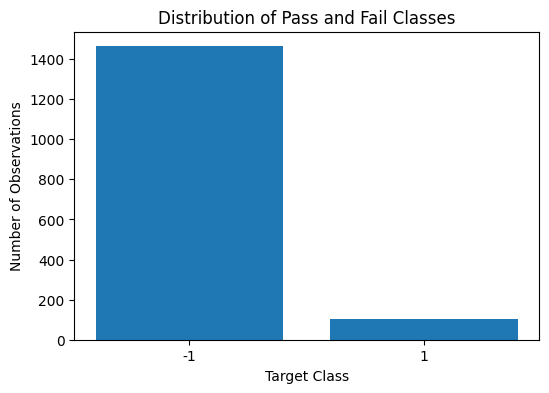

In [30]:
plt.figure(figsize=(6, 4))

plt.bar(
    target_counts.index.astype(str),
    target_counts.values
)

plt.xlabel("Target Class")
plt.ylabel("Number of Observations")
plt.title("Distribution of Pass and Fail Classes")

plt.show()

### Observation

The target distribution shows a significant class imbalance. The Pass class (`-1`) contains 1463 observations, whereas the Fail class (`1`) contains only 104 observations.

This imbalance may affect machine learning model performance because the model may become biased toward predicting the majority Pass class. Therefore, techniques such as SMOTE will be considered during the data preprocessing stage.

## 2. Target Class Percentage Distribution

The percentage distribution of the Pass and Fail classes is calculated to measure the degree of class imbalance in the dataset.

In [31]:
# Calculate the percentage distribution of target classes

target_percentage = y.value_counts(normalize=True) * 100

print("Target Class Percentage Distribution:")
print(target_percentage)

Target Class Percentage Distribution:
Target
-1    93.363114
 1     6.636886
Name: proportion, dtype: float64


### Observation

The percentage distribution confirms that the dataset is highly imbalanced. Approximately 93.36% of the observations belong to the Pass class (`-1`), while only 6.64% belong to the Fail class (`1`).

This imbalance is important because a machine learning model trained directly on the original dataset may become biased toward predicting the majority Pass class. Therefore, class-balancing techniques such as SMOTE will be considered during the data preprocessing and model training stage.

## 3. Univariate Analysis

Univariate analysis is performed to understand the distribution of individual sensor measurements. Histograms will be used to examine the distribution and variation of selected sensor features.

In [32]:
# Select a few sensor features for univariate analysis

selected_features = [
    X_cleaned.columns[0],
    X_cleaned.columns[1],
    X_cleaned.columns[2],
    X_cleaned.columns[3]
]

print("Selected features:")
print(selected_features)

Selected features:
['Sensor_1', 'Sensor_2', 'Sensor_3', 'Sensor_4']


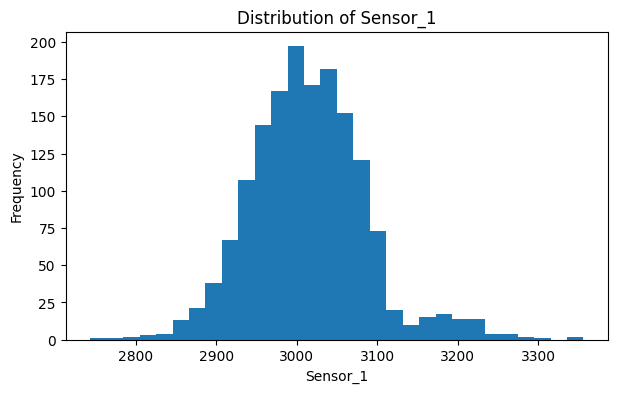

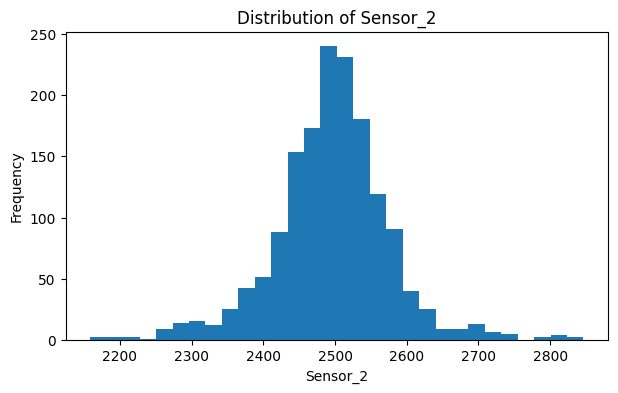

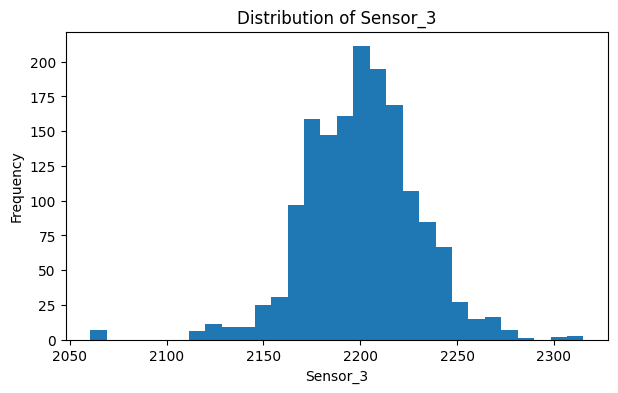

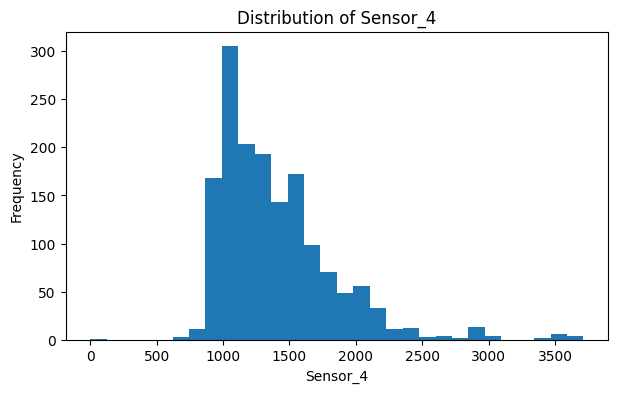

In [33]:
# Create histograms for selected sensor features

for feature in selected_features:

    plt.figure(figsize=(7, 4))

    plt.hist(X_cleaned[feature], bins=30)

    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {feature}")

    plt.show()

### Observation

The histograms show the distribution of selected sensor measurements. The distributions can be examined to identify differences in feature ranges, variation, concentration of values, and potential skewness.

Since the semiconductor dataset contains a large number of sensor features, only selected features are visualized for initial univariate analysis.

## 4. Boxplot Analysis

Boxplots are used to examine the spread of selected sensor measurements and identify potential outliers in the data.

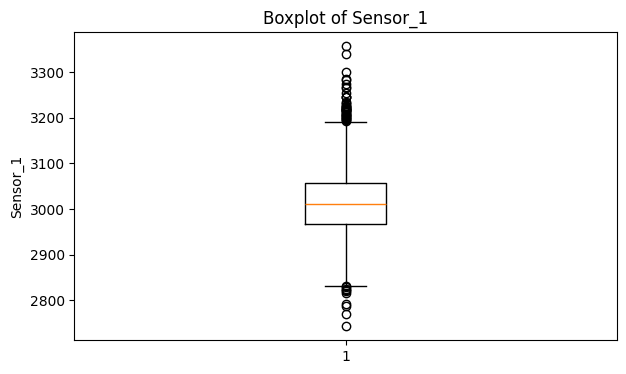

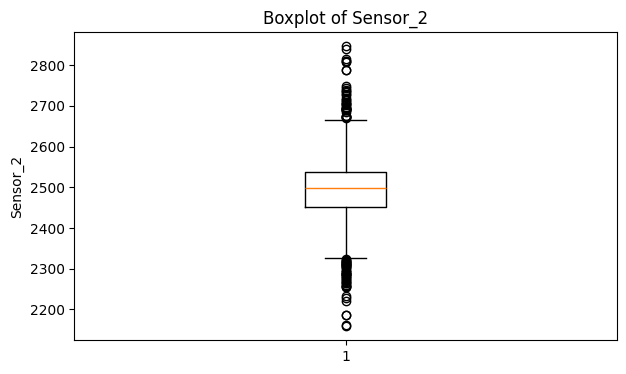

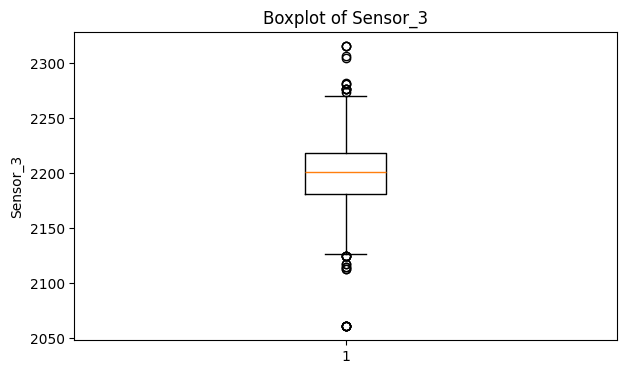

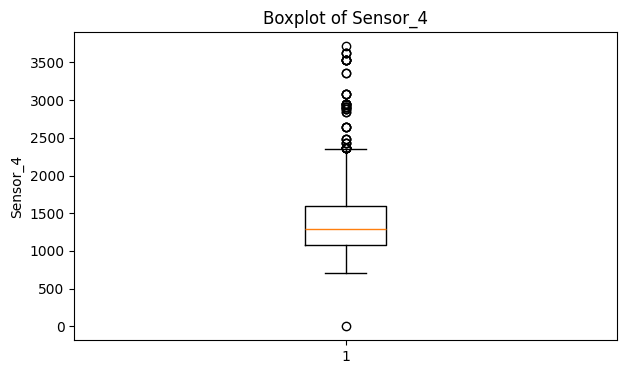

In [34]:
# Create boxplots for selected sensor features

for feature in selected_features:

    plt.figure(figsize=(7, 4))

    plt.boxplot(X_cleaned[feature])

    plt.ylabel(feature)
    plt.title(f"Boxplot of {feature}")

    plt.show()

## 5. Bivariate Analysis

Bivariate analysis is performed to examine the relationship between sensor measurements and the Target variable. The selected sensor features are compared across the Pass and Fail classes.

<Figure size 700x400 with 0 Axes>

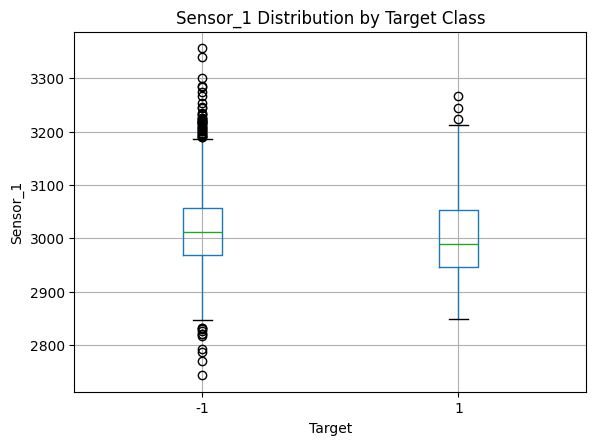

<Figure size 700x400 with 0 Axes>

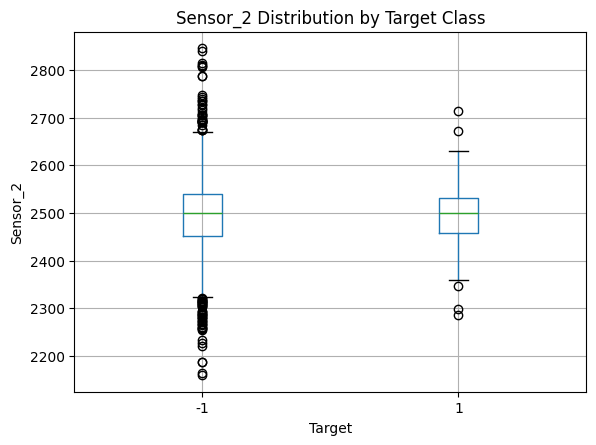

<Figure size 700x400 with 0 Axes>

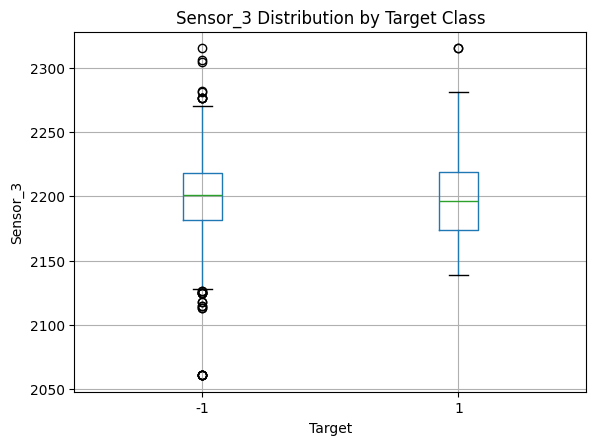

<Figure size 700x400 with 0 Axes>

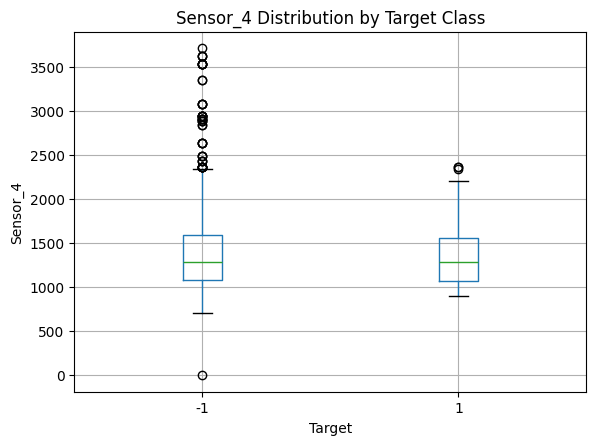

In [35]:
# Compare selected sensor features with the Target variable

for feature in selected_features:

    plt.figure(figsize=(7, 4))

    df_cleaned.boxplot(column=feature, by="Target")

    plt.title(f"{feature} Distribution by Target Class")
    plt.suptitle("")

    plt.xlabel("Target")
    plt.ylabel(feature)

    plt.show()

## 6. Correlation Analysis

Correlation analysis is performed to examine the relationships between selected sensor features. A correlation matrix helps identify positive and negative relationships between numerical variables.

In [36]:
# Calculate correlation between selected sensor features

correlation_matrix = X_cleaned[selected_features].corr()

print("Correlation Matrix:")
print(correlation_matrix)

Correlation Matrix:
          Sensor_1  Sensor_2  Sensor_3  Sensor_4
Sensor_1  1.000000 -0.144161  0.004667 -0.006665
Sensor_2 -0.144161  1.000000  0.005883 -0.008963
Sensor_3  0.004667  0.005883  1.000000  0.298810
Sensor_4 -0.006665 -0.008963  0.298810  1.000000


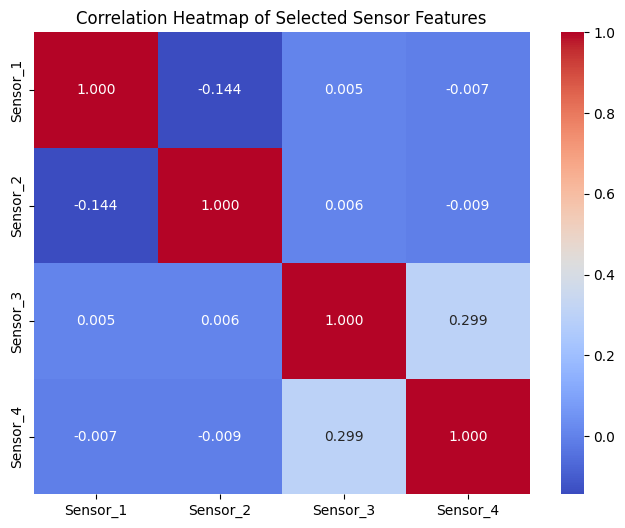

In [37]:
# Visualize the correlation matrix using a heatmap

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap of Selected Sensor Features")

plt.show()

### Observation

The correlation analysis shows that most selected sensor features have weak relationships with each other. Sensor_3 and Sensor_4 show the strongest positive correlation among the selected features, with a correlation coefficient of approximately 0.299.

Sensor_1 and Sensor_2 show a weak negative correlation of approximately -0.144. The remaining feature pairs have correlation values close to zero, indicating very weak linear relationships.

## 7. Sensor Feature Relationship with Target

The correlation between each sensor feature and the Target variable is calculated to identify sensor signals that have stronger linear relationships with the Pass/Fail yield outcome.

In [39]:
# Calculate correlation of each sensor feature with the Target

target_correlation = df_cleaned.corr()["Target"].drop("Target")

# Sort by absolute correlation value

top_target_correlations = (
    target_correlation.abs()
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 sensor features most correlated with Target:")
print(top_target_correlations)

Top 10 sensor features most correlated with Target:
Sensor_60     0.156008
Sensor_104    0.151230
Sensor_511    0.131662
Sensor_349    0.130807
Sensor_432    0.119936
Sensor_435    0.111312
Sensor_431    0.109115
Sensor_22     0.108333
Sensor_436    0.108260
Sensor_29     0.106987
Name: Target, dtype: float64


In [40]:
# Get the original signed correlations for the top 10 features

top_features = top_target_correlations.index

print("Correlation of top sensor features with Target:")
print(target_correlation[top_features])

Correlation of top sensor features with Target:
Sensor_60     0.156008
Sensor_104    0.151230
Sensor_511    0.131662
Sensor_349    0.130807
Sensor_432    0.119936
Sensor_435    0.111312
Sensor_431    0.109115
Sensor_22     0.108333
Sensor_436    0.108260
Sensor_29    -0.106987
Name: Target, dtype: float64


## 8. Top Sensor Features Correlated with Target

The top ten sensor features with the strongest absolute correlations with the Target variable are visualized to identify sensor signals that may be useful for predicting the Pass/Fail yield outcome.

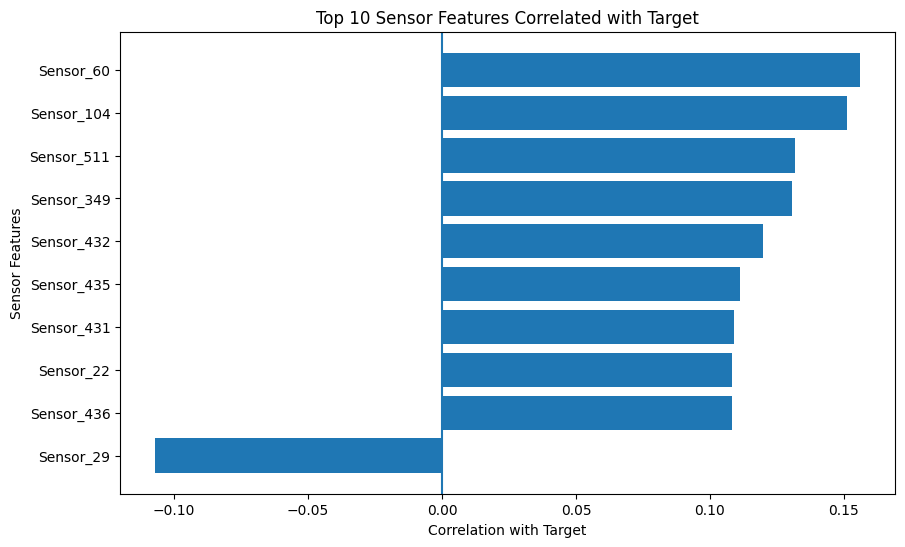

In [41]:
# Visualize the signed correlation of the top 10 sensors with Target

top_signed_correlations = target_correlation[top_features].sort_values()

plt.figure(figsize=(10, 6))

plt.barh(
    top_signed_correlations.index,
    top_signed_correlations.values
)

plt.xlabel("Correlation with Target")
plt.ylabel("Sensor Features")
plt.title("Top 10 Sensor Features Correlated with Target")

plt.axvline(x=0)

plt.show()

## 9. Multivariate Analysis

Multivariate analysis is performed to examine relationships among multiple sensor features simultaneously. The top sensor features identified through correlation with the Target variable are selected for further analysis.

In [42]:
# Create a correlation matrix for the top 10 sensor features

top_feature_corr_matrix = X_cleaned[top_features].corr()

print(top_feature_corr_matrix)

            Sensor_60  Sensor_104  Sensor_511  Sensor_349  Sensor_432  \
Sensor_60    1.000000    0.287741    0.217820    0.143566    0.095435   
Sensor_104   0.287741    1.000000    0.609703    0.154902    0.169045   
Sensor_511   0.217820    0.609703    1.000000    0.080090    0.139148   
Sensor_349   0.143566    0.154902    0.080090    1.000000    0.057978   
Sensor_432   0.095435    0.169045    0.139148    0.057978    1.000000   
Sensor_435   0.091269    0.150007    0.128687    0.051448    0.933361   
Sensor_431   0.072313    0.148871    0.138864    0.037937    0.899216   
Sensor_22   -0.025916    0.022263    0.059849   -0.001400    0.595531   
Sensor_436   0.085364    0.148091    0.128277    0.050816    0.929546   
Sensor_29   -0.258395   -0.337094   -0.243968   -0.126160   -0.219320   

            Sensor_435  Sensor_431  Sensor_22  Sensor_436  Sensor_29  
Sensor_60     0.091269    0.072313  -0.025916    0.085364  -0.258395  
Sensor_104    0.150007    0.148871   0.022263    0.148

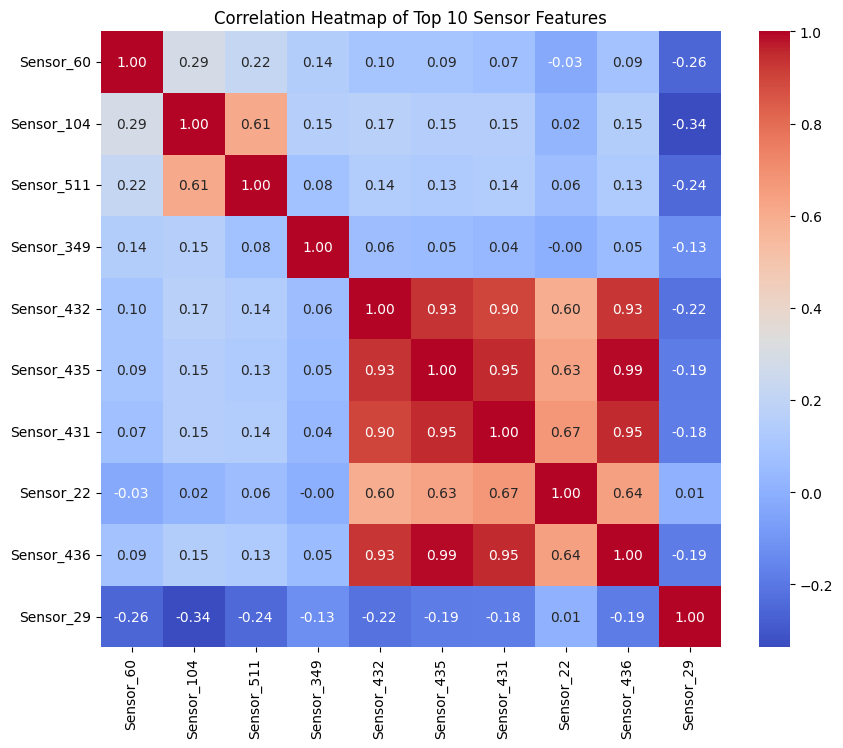

In [43]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    top_feature_corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap of Top 10 Sensor Features")

plt.show()

### Observation

The correlation heatmap shows the relationships among the top ten sensor features associated with the Target variable.

This multivariate analysis helps identify whether important sensor features are strongly related to each other or provide different information. Features with low correlations may contribute unique information, while highly correlated features may contain redundant information.

Further feature selection techniques will be applied during the machine learning stage to identify the most useful combination of sensor features for predicting the Pass/Fail yield outcome.

# Phase 4: Data Preprocessing

## 1. Separating Predictor Features and Target Variable

The cleaned dataset is divided into predictor features and the Target variable. The sensor measurements are used as predictor features, while the Target column represents the Pass/Fail yield outcome.

In [45]:
# Separate predictor features and target variable

X = df_cleaned.drop(columns=["Target"])
y = df_cleaned["Target"]

print("Predictor features shape:", X.shape)
print("Target shape:", y.shape)

Predictor features shape: (1567, 446)
Target shape: (1567,)


## 2. Train-Test Split

The dataset is divided into training and testing sets. The training data will be used to train and optimize machine learning models, while the testing data will be used to evaluate the final model performance.

Stratified splitting is used to preserve the original class distribution in both the training and testing datasets.

In [46]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training feature shape: (1253, 446)
Testing feature shape: (314, 446)

Training target distribution:
Target
-1    1170
 1      83
Name: count, dtype: int64

Testing target distribution:
Target
-1    293
 1     21
Name: count, dtype: int64


## 3. Feature Standardization

Sensor features may have different numerical ranges and scales. Standardization is applied so that the features have comparable scales.

The scaler is fitted only on the training data to prevent information from the testing data from leaking into the model training process.

In [47]:
from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Fit on training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform testing data using the same scaler
X_test_scaled = scaler.transform(X_test)

print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Scaled training data shape: (1253, 446)
Scaled testing data shape: (314, 446)


## 4. Handling Class Imbalance Using SMOTE

The training dataset is highly imbalanced, with significantly fewer Fail observations than Pass observations. SMOTE (Synthetic Minority Over-sampling Technique) is applied only to the training data to balance the classes.

The testing data is not modified and will be used to evaluate the model on unseen data with the original class distribution.

In [48]:
from imblearn.over_sampling import SMOTE

# Create SMOTE object
smote = SMOTE(random_state=42)

# Apply SMOTE only to the scaled training data
X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

print("\nSMOTE training feature shape:", X_train_smote.shape)

Before SMOTE:
Target
-1    1170
 1      83
Name: count, dtype: int64

After SMOTE:
Target
-1    1170
 1    1170
Name: count, dtype: int64

SMOTE training feature shape: (2340, 446)


## 5. Final Preprocessing Verification

After train-test splitting, feature standardization, and SMOTE balancing, the final datasets are verified before proceeding to machine learning model training.

SMOTE is applied only to the training data, while the testing data remains unchanged.

In [49]:
print("Final Training Data After SMOTE:")
print("X_train_smote shape:", X_train_smote.shape)

print("\nTraining Target Distribution:")
print(y_train_smote.value_counts())

print("\nOriginal Test Data:")
print("X_test_scaled shape:", X_test_scaled.shape)

print("\nTesting Target Distribution:")
print(y_test.value_counts())

Final Training Data After SMOTE:
X_train_smote shape: (2340, 446)

Training Target Distribution:
Target
-1    1170
 1    1170
Name: count, dtype: int64

Original Test Data:
X_test_scaled shape: (314, 446)

Testing Target Distribution:
Target
-1    293
 1     21
Name: count, dtype: int64


# Phase 5: Model Training and Evaluation

## 1. Logistic Regression

Logistic Regression is used as the baseline classification model for predicting the Pass/Fail yield outcome. The model is trained using the balanced training dataset created with SMOTE.

In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Create Logistic Regression model

logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

# Train the model using SMOTE-balanced training data

logistic_model.fit(X_train_smote, y_train_smote)

# Predictions

y_train_pred_logistic = logistic_model.predict(X_train_smote)
y_test_pred_logistic = logistic_model.predict(X_test_scaled)

# Accuracy

train_accuracy_logistic = accuracy_score(
    y_train_smote,
    y_train_pred_logistic
)

test_accuracy_logistic = accuracy_score(
    y_test,
    y_test_pred_logistic
)

print("Training Accuracy:", train_accuracy_logistic)
print("Testing Accuracy:", test_accuracy_logistic)

Training Accuracy: 0.9952991452991453
Testing Accuracy: 0.8312101910828026


In [51]:
from sklearn.metrics import classification_report

print("Classification Report for Logistic Regression:\n")

print(
    classification_report(
        y_test,
        y_test_pred_logistic
    )
)

Classification Report for Logistic Regression:

              precision    recall  f1-score   support

          -1       0.93      0.88      0.91       293
           1       0.08      0.14      0.10        21

    accuracy                           0.83       314
   macro avg       0.51      0.51      0.50       314
weighted avg       0.88      0.83      0.85       314



## Logistic Regression Confusion Matrix

A confusion matrix is used to examine the number of correct and incorrect predictions made by the Logistic Regression model for the Pass and Fail classes.

Confusion Matrix:
[[258  35]
 [ 18   3]]


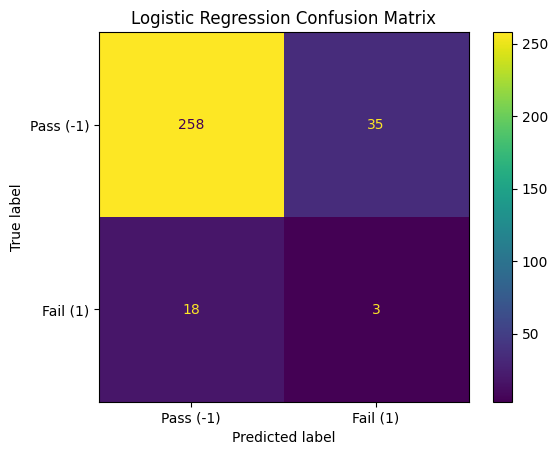

In [52]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create confusion matrix

cm_logistic = confusion_matrix(
    y_test,
    y_test_pred_logistic,
    labels=[-1, 1]
)

print("Confusion Matrix:")
print(cm_logistic)

# Visualize confusion matrix

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=["Pass (-1)", "Fail (1)"]
)

disp.plot()

plt.title("Logistic Regression Confusion Matrix")

plt.show()

### Observation

The Logistic Regression confusion matrix shows that the model correctly predicted 258 Pass observations and only 3 Fail observations.

The model incorrectly classified 18 actual Fail observations as Pass. Since detecting manufacturing failures is important in this project, this poor Fail-class detection indicates that Logistic Regression may not be suitable as the final model.

Therefore, additional machine learning models will be trained and compared to identify a model with better performance for both classes.

## 2. Random Forest Classifier

Random Forest is an ensemble machine learning algorithm that combines multiple decision trees to perform classification. It is used to capture complex and non-linear relationships between sensor features and the Pass/Fail yield outcome.

In [54]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# Train the model

rf_model.fit(X_train_smote, y_train_smote)

# Predictions

y_train_pred_rf = rf_model.predict(X_train_smote)
y_test_pred_rf = rf_model.predict(X_test_scaled)

# Accuracy

train_accuracy_rf = accuracy_score(
    y_train_smote,
    y_train_pred_rf
)

test_accuracy_rf = accuracy_score(
    y_test,
    y_test_pred_rf
)

print("Training Accuracy:", train_accuracy_rf)
print("Testing Accuracy:", test_accuracy_rf)

Training Accuracy: 1.0
Testing Accuracy: 0.9299363057324841
Training Accuracy: 1.0
Testing Accuracy: 0.9299363057324841


In [55]:
print("Classification Report for Random Forest:\n")

print(
    classification_report(
        y_test,
        y_test_pred_rf
    )
)

Classification Report for Random Forest:

              precision    recall  f1-score   support

          -1       0.93      1.00      0.96       293
           1       0.00      0.00      0.00        21

    accuracy                           0.93       314
   macro avg       0.47      0.50      0.48       314
weighted avg       0.87      0.93      0.90       314



Confusion Matrix:
[[292   1]
 [ 21   0]]


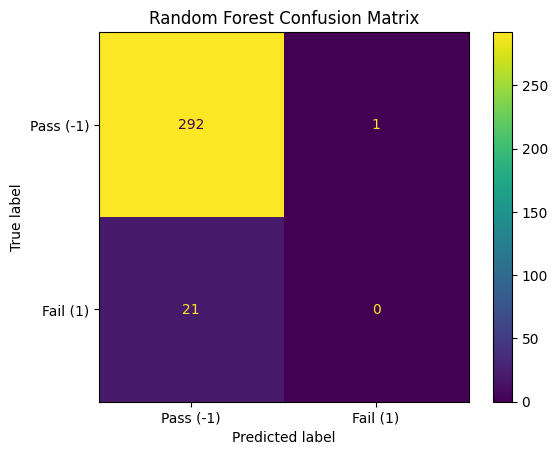

In [56]:
# Random Forest Confusion Matrix

cm_rf = confusion_matrix(
    y_test,
    y_test_pred_rf,
    labels=[-1, 1]
)

print("Confusion Matrix:")
print(cm_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Pass (-1)", "Fail (1)"]
)

disp.plot()

plt.title("Random Forest Confusion Matrix")

plt.show()

### Observation

The Random Forest model achieved high overall accuracy; however, the confusion matrix shows that it failed to correctly identify any Fail observations.

All 21 actual Fail observations were predicted as Pass. Therefore, accuracy alone is not sufficient for evaluating this imbalanced dataset.

The Fail-class recall and F1-score are more important evaluation metrics for this project. Further models will be trained and compared to improve the detection of semiconductor manufacturing failures.

## 3. Support Vector Machine (SVM)

A Support Vector Machine classifier is used as a third machine learning model to predict the Pass/Fail yield outcome. SVM can model complex decision boundaries and may perform differently from Logistic Regression and Random Forest.

In [57]:
from sklearn.svm import SVC

# Create SVM model

svm_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    random_state=42
)

# Train the model

svm_model.fit(X_train_smote, y_train_smote)

# Predictions

y_train_pred_svm = svm_model.predict(X_train_smote)
y_test_pred_svm = svm_model.predict(X_test_scaled)

# Accuracy

train_accuracy_svm = accuracy_score(
    y_train_smote,
    y_train_pred_svm
)

test_accuracy_svm = accuracy_score(
    y_test,
    y_test_pred_svm
)

print("Training Accuracy:", train_accuracy_svm)
print("Testing Accuracy:", test_accuracy_svm)

Training Accuracy: 0.9995726495726496
Testing Accuracy: 0.9331210191082803


In [58]:
print("Classification Report for SVM:\n")

print(
    classification_report(
        y_test,
        y_test_pred_svm
    )
)

Classification Report for SVM:

              precision    recall  f1-score   support

          -1       0.94      1.00      0.97       293
           1       0.50      0.05      0.09        21

    accuracy                           0.93       314
   macro avg       0.72      0.52      0.53       314
weighted avg       0.91      0.93      0.91       314



Confusion Matrix:
[[292   1]
 [ 20   1]]


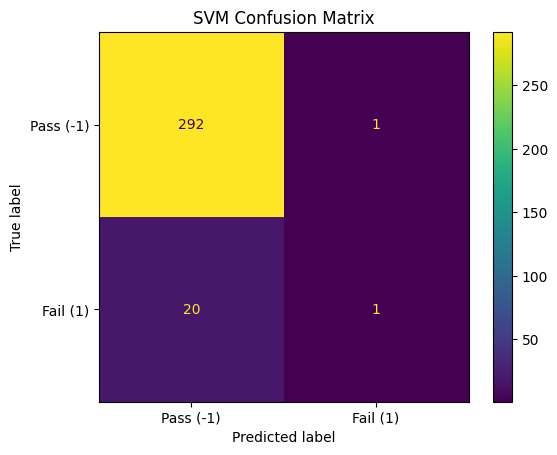

In [59]:
# Create SVM confusion matrix

cm_svm = confusion_matrix(
    y_test,
    y_test_pred_svm,
    labels=[-1, 1]
)

print("Confusion Matrix:")
print(cm_svm)

# Display confusion matrix

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=["Pass (-1)", "Fail (1)"]
)

disp.plot()

plt.title("SVM Confusion Matrix")

plt.show()

## 4. Cross-Validation

Stratified 5-Fold Cross-Validation is used to evaluate the stability and generalization performance of the machine learning models.

Stratified splitting preserves the class distribution in each fold. Since the dataset is imbalanced, F1-score is also considered in addition to accuracy.

In [60]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import make_scorer, f1_score

# Create Stratified 5-Fold Cross-Validation

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Calculate cross-validation accuracy

logistic_cv_accuracy = cross_val_score(
    logistic_model,
    X_train_smote,
    y_train_smote,
    cv=cv,
    scoring="accuracy"
)

# Calculate cross-validation F1-score for Fail class (1)

logistic_cv_f1 = cross_val_score(
    logistic_model,
    X_train_smote,
    y_train_smote,
    cv=cv,
    scoring=make_scorer(f1_score, pos_label=1)
)

print("Logistic Regression Cross-Validation Accuracy:")
print(logistic_cv_accuracy)

print("\nMean CV Accuracy:", logistic_cv_accuracy.mean())

print("\nLogistic Regression Cross-Validation F1 Scores:")
print(logistic_cv_f1)

print("\nMean CV F1 Score:", logistic_cv_f1.mean())

Logistic Regression Cross-Validation Accuracy:
[0.93803419 0.92094017 0.94871795 0.93162393 0.92094017]

Mean CV Accuracy: 0.9320512820512821

Logistic Regression Cross-Validation F1 Scores:
[0.9416499  0.92555332 0.95020747 0.936      0.92673267]

Mean CV F1 Score: 0.936028672292578


In [61]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, f1_score

# Create Stratified 5-Fold Cross-Validation

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Create a pipeline
# Scaling and SMOTE are applied separately within each training fold

logistic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

# Cross-validation accuracy

cv_accuracy = cross_val_score(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)

# Cross-validation F1-score for Fail class (1)

cv_f1 = cross_val_score(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=make_scorer(f1_score, pos_label=1)
)

print("Cross-Validation Accuracy Scores:")
print(cv_accuracy)

print("\nMean CV Accuracy:", cv_accuracy.mean())

print("\nCross-Validation F1 Scores for Fail Class:")
print(cv_f1)

print("\nMean CV F1 Score:", cv_f1.mean())

Cross-Validation Accuracy Scores:
[0.86055777 0.81673307 0.87250996 0.828      0.852     ]

Mean CV Accuracy: 0.8459601593625499

Cross-Validation F1 Scores for Fail Class:
[0.14634146 0.20689655 0.2        0.04444444 0.30188679]

Mean CV F1 Score: 0.17991385040720936


In [62]:
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# Create Random Forest pipeline

rf_pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

# Cross-validation accuracy

rf_cv_accuracy = cross_val_score(
    rf_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)

# Cross-validation F1-score for Fail class

rf_cv_f1 = cross_val_score(
    rf_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=make_scorer(f1_score, pos_label=1)
)

print("Random Forest Cross-Validation Accuracy Scores:")
print(rf_cv_accuracy)

print("\nMean CV Accuracy:", rf_cv_accuracy.mean())

print("\nRandom Forest Cross-Validation F1 Scores for Fail Class:")
print(rf_cv_f1)

print("\nMean CV F1 Score:", rf_cv_f1.mean())

Random Forest Cross-Validation Accuracy Scores:
[0.92828685 0.92828685 0.92828685 0.932      0.932     ]

Mean CV Accuracy: 0.9297721115537849

Random Forest Cross-Validation F1 Scores for Fail Class:
[0.1 0.1 0.  0.  0. ]

Mean CV F1 Score: 0.04


In [63]:
from sklearn.svm import SVC

# Create SVM pipeline

svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("model", SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        random_state=42
    ))
])

# Cross-validation accuracy

svm_cv_accuracy = cross_val_score(
    svm_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)

# Cross-validation F1-score for Fail class

svm_cv_f1 = cross_val_score(
    svm_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=make_scorer(f1_score, pos_label=1)
)

print("SVM Cross-Validation Accuracy Scores:")
print(svm_cv_accuracy)

print("\nMean CV Accuracy:", svm_cv_accuracy.mean())

print("\nSVM Cross-Validation F1 Scores for Fail Class:")
print(svm_cv_f1)

print("\nMean CV F1 Score:", svm_cv_f1.mean())

SVM Cross-Validation Accuracy Scores:
[0.92828685 0.91633466 0.92828685 0.936      0.928     ]

Mean CV Accuracy: 0.9273816733067729

SVM Cross-Validation F1 Scores for Fail Class:
[0.         0.         0.         0.         0.18181818]

Mean CV F1 Score: 0.03636363636363636


## 5. Hyperparameter Tuning Using GridSearchCV

GridSearchCV is used to test different combinations of model hyperparameters and identify the configuration that provides the best performance.

Since the dataset is imbalanced, the F1-score for the Fail class (`1`) is used as the scoring metric.

In [64]:
from sklearn.model_selection import GridSearchCV

# Hyperparameter values to test

param_grid_logistic = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__solver": ["liblinear", "lbfgs"]
}

# GridSearchCV

grid_logistic = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=param_grid_logistic,
    cv=cv,
    scoring=make_scorer(f1_score, pos_label=1),
    n_jobs=-1
)

# Train GridSearch

grid_logistic.fit(X_train, y_train)

print("Best Parameters:")
print(grid_logistic.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(grid_logistic.best_score_)

Best Parameters:
{'model__C': 0.01, 'model__solver': 'lbfgs'}

Best Cross-Validation F1 Score:
0.21116151547174195


In [65]:
# Get the best tuned pipeline

best_logistic_model = grid_logistic.best_estimator_

# Predict on the original untouched test data

y_test_pred_tuned_logistic = best_logistic_model.predict(X_test)

# Calculate accuracy

tuned_logistic_accuracy = accuracy_score(
    y_test,
    y_test_pred_tuned_logistic
)

print("Tuned Logistic Regression Test Accuracy:")
print(tuned_logistic_accuracy)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_test_pred_tuned_logistic
    )
)

Tuned Logistic Regression Test Accuracy:
0.8057324840764332

Classification Report:
              precision    recall  f1-score   support

          -1       0.94      0.85      0.89       293
           1       0.08      0.19      0.12        21

    accuracy                           0.81       314
   macro avg       0.51      0.52      0.50       314
weighted avg       0.88      0.81      0.84       314



Confusion Matrix:
[[249  44]
 [ 17   4]]


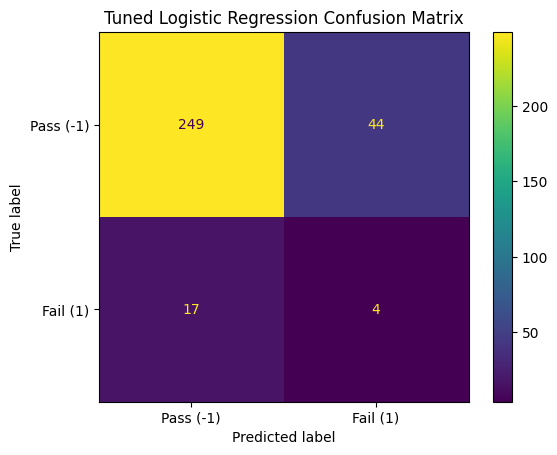

In [66]:
# Confusion Matrix for Tuned Logistic Regression

cm_tuned_logistic = confusion_matrix(
    y_test,
    y_test_pred_tuned_logistic,
    labels=[-1, 1]
)

print("Confusion Matrix:")
print(cm_tuned_logistic)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tuned_logistic,
    display_labels=["Pass (-1)", "Fail (1)"]
)

disp.plot()

plt.title("Tuned Logistic Regression Confusion Matrix")

plt.show()

In [67]:
from sklearn.model_selection import GridSearchCV

# Hyperparameters to test

param_grid_rf = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

# GridSearchCV

grid_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid_rf,
    cv=cv,
    scoring=make_scorer(f1_score, pos_label=1),
    n_jobs=-1
)

# Train GridSearchCV

grid_rf.fit(X_train, y_train)

print("Best Parameters:")
print(grid_rf.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(grid_rf.best_score_)

Best Parameters:
{'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 100}

Best Cross-Validation F1 Score:
0.17139544513457555


In [68]:
# Get the best tuned Random Forest pipeline

best_rf_model = grid_rf.best_estimator_

# Predict using the untouched test dataset

y_test_pred_tuned_rf = best_rf_model.predict(X_test)

# Calculate accuracy

tuned_rf_accuracy = accuracy_score(
    y_test,
    y_test_pred_tuned_rf
)

print("Tuned Random Forest Test Accuracy:")
print(tuned_rf_accuracy)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_test_pred_tuned_rf
    )
)

Tuned Random Forest Test Accuracy:
0.9235668789808917

Classification Report:
              precision    recall  f1-score   support

          -1       0.93      0.99      0.96       293
           1       0.00      0.00      0.00        21

    accuracy                           0.92       314
   macro avg       0.47      0.49      0.48       314
weighted avg       0.87      0.92      0.90       314



In [69]:
from sklearn.model_selection import GridSearchCV

# Hyperparameters to test

param_grid_svm = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__kernel": ["linear", "rbf"],
    "model__gamma": ["scale", "auto"]
}

grid_svm = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid_svm,
    cv=cv,
    scoring=make_scorer(f1_score, pos_label=1),
    n_jobs=-1
)

# Train GridSearchCV

grid_svm.fit(X_train, y_train)

print("Best Parameters:")
print(grid_svm.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(grid_svm.best_score_)

Best Parameters:
{'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'linear'}

Best Cross-Validation F1 Score:
0.17772693891176145


In [70]:
# Get the best tuned SVM pipeline

best_svm_model = grid_svm.best_estimator_

# Predict on the untouched test dataset

y_test_pred_tuned_svm = best_svm_model.predict(X_test)

# Calculate test accuracy

tuned_svm_accuracy = accuracy_score(
    y_test,
    y_test_pred_tuned_svm
)

print("Tuned SVM Test Accuracy:")
print(tuned_svm_accuracy)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_test_pred_tuned_svm
    )
)

Tuned SVM Test Accuracy:
0.856687898089172

Classification Report:
              precision    recall  f1-score   support

          -1       0.94      0.90      0.92       293
           1       0.12      0.19      0.15        21

    accuracy                           0.86       314
   macro avg       0.53      0.55      0.54       314
weighted avg       0.89      0.86      0.87       314



Confusion Matrix:
[[265  28]
 [ 17   4]]


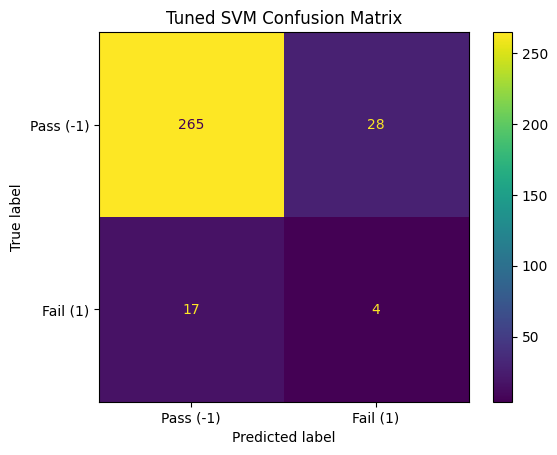

In [71]:
# Confusion Matrix for Tuned SVM

cm_tuned_svm = confusion_matrix(
    y_test,
    y_test_pred_tuned_svm,
    labels=[-1, 1]
)

print("Confusion Matrix:")
print(cm_tuned_svm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tuned_svm,
    display_labels=["Pass (-1)", "Fail (1)"]
)

disp.plot()

plt.title("Tuned SVM Confusion Matrix")

plt.show()

In [72]:
import pandas as pd
import numpy as np

# Get the trained SVM model from the pipeline
svm_final = best_svm_model.named_steps["model"]

# Get feature importance using absolute coefficient values
feature_importance = pd.Series(
    np.abs(svm_final.coef_[0]),
    index=X_train.columns
)

# Sort features from most important to least important
feature_importance = feature_importance.sort_values(
    ascending=False
)

print("Top 20 Most Important Sensor Features:")
print(feature_importance.head(20))

Top 20 Most Important Sensor Features:
Sensor_60     1.372249
Sensor_217    1.281340
Sensor_189    1.170702
Sensor_125    1.162362
Sensor_26     1.143091
Sensor_133    1.106909
Sensor_62     1.104693
Sensor_426    1.070861
Sensor_355    1.005891
Sensor_278    1.000092
Sensor_27     0.965420
Sensor_57     0.964915
Sensor_42     0.942681
Sensor_564    0.934145
Sensor_306    0.918516
Sensor_65     0.883837
Sensor_169    0.872522
Sensor_334    0.861246
Sensor_416    0.854434
Sensor_216    0.796058
dtype: float64


In [73]:
# Select the top 20 features

top_20_features = feature_importance.head(20).index.tolist()

print("Number of selected features:", len(top_20_features))
print("\nSelected features:")
print(top_20_features)

# Create reduced datasets

X_train_top20 = X_train[top_20_features]
X_test_top20 = X_test[top_20_features]

print("\nTraining shape:", X_train_top20.shape)
print("Testing shape:", X_test_top20.shape)

Number of selected features: 20

Selected features:
['Sensor_60', 'Sensor_217', 'Sensor_189', 'Sensor_125', 'Sensor_26', 'Sensor_133', 'Sensor_62', 'Sensor_426', 'Sensor_355', 'Sensor_278', 'Sensor_27', 'Sensor_57', 'Sensor_42', 'Sensor_564', 'Sensor_306', 'Sensor_65', 'Sensor_169', 'Sensor_334', 'Sensor_416', 'Sensor_216']

Training shape: (1253, 20)
Testing shape: (314, 20)


In [74]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Create SVM pipeline for Top 20 features

svm_top20_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("model", SVC(
        C=1,
        kernel="linear",
        gamma="scale",
        random_state=42
    ))
])

# Train the model

svm_top20_pipeline.fit(X_train_top20, y_train)

# Predict on test data

y_test_pred_top20 = svm_top20_pipeline.predict(X_test_top20)

# Calculate accuracy

top20_accuracy = accuracy_score(
    y_test,
    y_test_pred_top20
)

print("Top 20 Features SVM Test Accuracy:")
print(top20_accuracy)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_test_pred_top20
    )
)

Top 20 Features SVM Test Accuracy:
0.7133757961783439

Classification Report:
              precision    recall  f1-score   support

          -1       0.96      0.72      0.82       293
           1       0.14      0.62      0.22        21

    accuracy                           0.71       314
   macro avg       0.55      0.67      0.52       314
weighted avg       0.91      0.71      0.78       314



Confusion Matrix:
[[211  82]
 [  8  13]]


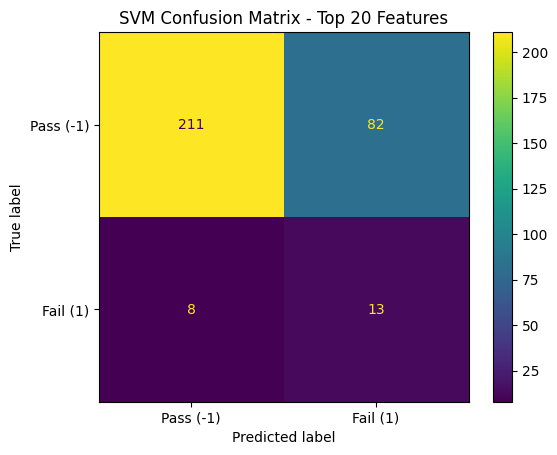

In [75]:
# Confusion Matrix for Top 20 Features SVM

cm_top20 = confusion_matrix(
    y_test,
    y_test_pred_top20,
    labels=[-1, 1]
)

print("Confusion Matrix:")
print(cm_top20)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_top20,
    display_labels=["Pass (-1)", "Fail (1)"]
)

disp.plot()

plt.title("SVM Confusion Matrix - Top 20 Features")

plt.show()

In [76]:
# Select Top 50 important features

top_50_features = feature_importance.head(50).index.tolist()

# Create reduced datasets

X_train_top50 = X_train[top_50_features]
X_test_top50 = X_test[top_50_features]

print("Number of selected features:", len(top_50_features))
print("Training shape:", X_train_top50.shape)
print("Testing shape:", X_test_top50.shape)

Number of selected features: 50
Training shape: (1253, 50)
Testing shape: (314, 50)


In [77]:
# Train SVM using Top 50 important features

svm_top50_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("model", SVC(
        C=1,
        kernel="linear",
        gamma="scale",
        random_state=42
    ))
])

# Train the model
svm_top50_pipeline.fit(X_train_top50, y_train)

# Predict on test data
y_test_pred_top50 = svm_top50_pipeline.predict(X_test_top50)

# Calculate accuracy
top50_accuracy = accuracy_score(
    y_test,
    y_test_pred_top50
)

print("Top 50 Features SVM Test Accuracy:")
print(top50_accuracy)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_test_pred_top50
    )
)

Top 50 Features SVM Test Accuracy:
0.7515923566878981

Classification Report:
              precision    recall  f1-score   support

          -1       0.95      0.78      0.85       293
           1       0.11      0.38      0.17        21

    accuracy                           0.75       314
   macro avg       0.53      0.58      0.51       314
weighted avg       0.89      0.75      0.81       314



In [78]:
# Select Top 100 important features

top_100_features = feature_importance.head(100).index.tolist()

# Create datasets

X_train_top100 = X_train[top_100_features]
X_test_top100 = X_test[top_100_features]

print("Number of selected features:", len(top_100_features))
print("Training shape:", X_train_top100.shape)
print("Testing shape:", X_test_top100.shape)

Number of selected features: 100
Training shape: (1253, 100)
Testing shape: (314, 100)


In [79]:
# Train SVM using Top 100 important features

svm_top100_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("model", SVC(
        C=1,
        kernel="linear",
        gamma="scale",
        random_state=42
    ))
])

# Train the model
svm_top100_pipeline.fit(X_train_top100, y_train)

# Predict on test data
y_test_pred_top100 = svm_top100_pipeline.predict(X_test_top100)

# Calculate accuracy
top100_accuracy = accuracy_score(
    y_test,
    y_test_pred_top100
)

print("Top 100 Features SVM Test Accuracy:")
print(top100_accuracy)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_test_pred_top100
    )
)

Top 100 Features SVM Test Accuracy:
0.8152866242038217

Classification Report:
              precision    recall  f1-score   support

          -1       0.93      0.86      0.90       293
           1       0.07      0.14      0.09        21

    accuracy                           0.82       314
   macro avg       0.50      0.50      0.50       314
weighted avg       0.88      0.82      0.84       314



In [80]:
import joblib

# Save the final Top 20 feature SVM model
joblib.dump(
    svm_top20_pipeline,
    "final_semiconductor_svm_model.pkl"
)

# Save the selected feature names
joblib.dump(
    top_20_features,
    "selected_top20_features.pkl"
)

print("Final model saved successfully!")
print("Selected features saved successfully!")

Final model saved successfully!
Selected features saved successfully!


# 6. Results and Discussion

This section presents the results obtained from the machine learning models developed for predicting the Pass/Fail yield of semiconductor manufacturing entities.

The dataset was highly imbalanced, with 1463 Pass observations and 104 Fail observations. Therefore, overall accuracy alone was not sufficient for evaluating model performance. Special attention was given to the Recall and F1-score of the Fail class.

### 6.1 Dataset and Preprocessing Results

The original dataset contained 1567 observations and 591 columns, consisting of 590 sensor features and one target variable.

During data cleansing, 28 sensor features containing more than 50% missing values were removed. Missing values in the remaining features were treated using median imputation.

After removing high-missing-value features and irrelevant or redundant features, 446 predictor features were used for model development.

The target distribution was highly imbalanced:

- Pass (-1): 1463 observations (93.36%)
- Fail (1): 104 observations (6.64%)

To address class imbalance, SMOTE was applied only to the training data.

### 6.2 Model Performance and Comparison

Three machine learning models were initially developed and evaluated:

1. Logistic Regression
2. Random Forest Classifier
3. Support Vector Machine (SVM)

Because the dataset was highly imbalanced, model evaluation was based not only on overall accuracy but also on the Precision, Recall, and F1-score of the Fail class.

### Initial Model Performance

| Model | Training Accuracy | Test Accuracy | Fail Recall | Fail F1-score |
|---|---:|---:|---:|---:|
| Logistic Regression | 99.53% | 83.12% | 0.14 | 0.10 |
| Random Forest | 100.00% | 92.99% | 0.00 | 0.00 |
| SVM | 99.96% | 93.31% | 0.05 | 0.09 |

The results show that Random Forest and SVM achieved higher overall accuracy. However, both models performed poorly in detecting the minority Fail class.

Logistic Regression achieved lower overall accuracy but detected more Fail cases than the initial Random Forest and SVM models. This demonstrates that accuracy alone can be misleading when evaluating an imbalanced dataset.

### 6.3 Cross-Validation Results

Stratified 5-Fold Cross-Validation was performed to evaluate the stability and generalization performance of the models.

SMOTE was applied inside the training folds using a machine learning pipeline to avoid data leakage.

| Model | Mean CV Accuracy | Mean CV F1-score for Fail Class |
|---|---:|---:|
| Logistic Regression | 84.60% | 0.180 |
| Random Forest | 92.98% | 0.040 |
| SVM | 92.74% | 0.036 |

Random Forest achieved the highest cross-validation accuracy. However, Logistic Regression achieved the highest F1-score for the Fail class.

Therefore, further hyperparameter tuning and feature selection were performed to improve minority-class detection.

### 6.4 Hyperparameter Tuning Results

GridSearchCV was used to identify better hyperparameter combinations for Logistic Regression, Random Forest, and Support Vector Machine. Since the dataset was highly imbalanced, the F1-score of the Fail class was used as an important scoring metric during hyperparameter tuning.

### Tuned Model Results

| Model | Best Parameters | Best CV F1 | Test Accuracy | Fail Recall | Fail F1-score |
|---|---|---:|---:|---:|---:|
| Logistic Regression | C=0.01, solver=lbfgs | 0.211 | 80.57% | 0.19 | 0.12 |
| Random Forest | n_estimators=100, max_depth=10, min_samples_split=5, min_samples_leaf=1 | 0.171 | 92.36% | 0.00 | 0.00 |
| SVM | C=1, kernel=linear, gamma=scale | 0.178 | 85.67% | 0.19 | **0.15** |

The tuned SVM achieved the highest Fail-class F1-score among the three tuned models.

Although Random Forest achieved the highest overall test accuracy, it failed to identify Fail observations. Therefore, it was not considered the most appropriate model for failure detection.

The tuned SVM provided a better balance between overall classification performance and detection of the minority Fail class.

### 6.5 Feature Selection Results

Feature importance was analysed using the absolute values of the coefficients obtained from the linear SVM model. The sensor features were ranked according to their influence on the model's decision boundary.

The top 20 important sensor features included:

Sensor_60, Sensor_217, Sensor_189, Sensor_125, Sensor_26, Sensor_133, Sensor_62, Sensor_426, Sensor_355, Sensor_278, Sensor_27, Sensor_57, Sensor_42, Sensor_564, Sensor_306, Sensor_65, Sensor_169, Sensor_334, Sensor_416, and Sensor_216.

Different numbers of selected features were then tested using the tuned linear SVM model.

### Feature Set Performance Comparison

| Feature Set | Number of Features | Test Accuracy | Fail Recall | Fail F1-score |
|---|---:|---:|---:|---:|
| Top 20 Features | 20 | 71.34% | **0.62** | **0.22** |
| Top 50 Features | 50 | 75.16% | 0.38 | 0.17 |
| Top 100 Features | 100 | 81.53% | 0.14 | 0.09 |
| All Features | 446 | **85.67%** | 0.19 | 0.15 |

The results demonstrate that all sensor features were not equally useful for detecting semiconductor manufacturing failures.

The model using all 446 features achieved the highest overall accuracy. However, the model using only the Top 20 selected features achieved the highest Recall and F1-score for the Fail class.

The Top 20 feature model correctly detected 13 out of 21 Fail observations, while using only a small subset of the original sensor features.

This demonstrates that feature selection can reduce model complexity and identify important sensor signals associated with yield failures. However, the Top 20 feature model also produced a larger number of false alarms, which reduced its overall accuracy.

### 6.6 Final Model Selection

The final model was selected by considering the highly imbalanced nature of the dataset and the importance of detecting Fail observations.

Although Random Forest achieved the highest overall accuracy, it failed to identify any Fail observations. Therefore, it was not selected as the final model.

The tuned linear SVM using the Top 20 selected sensor features was chosen as the final approach because it achieved the highest Fail-class Recall and F1-score among the evaluated feature configurations.

Final Model:

- Model: Support Vector Machine (Linear Kernel)
- Selected Features: Top 20 sensor features
- Test Accuracy: 71.34%
- Fail Recall: 0.62
- Fail F1-score: 0.22
- Fail Cases Correctly Detected: 13 out of 21

The results indicate that reducing the number of features can improve the ability to detect semiconductor manufacturing failures. Therefore, the selected Top 20 sensor features may provide useful information for identifying yield excursions in the manufacturing process.

# 7. Conclusion

This project focused on predicting semiconductor manufacturing Pass/Fail yield outcomes using sensor data and machine learning techniques.

The dataset contained 1567 observations with 590 sensor features and a highly imbalanced target variable. After data preprocessing, features with a high percentage of missing values were removed, remaining missing values were handled, and redundant features were removed. A total of 446 predictor features were used for the initial machine learning experiments.

Logistic Regression, Random Forest, and Support Vector Machine models were developed and evaluated. Although Random Forest and SVM achieved higher overall accuracy, overall accuracy alone was found to be insufficient because the Fail class represented only a small proportion of the dataset.

Cross-validation and GridSearchCV hyperparameter tuning were performed to improve model evaluation and optimization. The tuned SVM provided better minority-class performance than the other evaluated full-feature models.

Feature selection was then performed using the coefficients of the linear SVM model. Experiments using the Top 20, Top 50, Top 100, and all 446 features showed that using fewer features could improve the detection of Fail observations.

The Top 20 feature SVM achieved a Fail Recall of 0.62 and a Fail F1-score of 0.22, correctly detecting 13 out of 21 Fail observations in the test dataset. Although its overall accuracy was lower than the model using all features, it was more effective at identifying manufacturing failures.

Therefore, the results demonstrate that all sensor features are not equally useful for predicting semiconductor yield outcomes. Feature selection can reduce model complexity and help identify sensor signals that are more strongly associated with manufacturing failures.

# 8. Future Improvements

The following improvements can be considered for future work:

1. Collect additional Fail observations to reduce the severe class imbalance in the dataset.

2. Experiment with other imbalance-handling techniques, such as class weighting, Borderline-SMOTE, and ADASYN.

3. Perform more advanced feature selection techniques to identify the optimal number of sensor features.

4. Evaluate additional machine learning models such as XGBoost, LightGBM, and other ensemble methods.

5. Perform threshold optimization to improve the balance between detecting Fail observations and reducing false alarms.

6. Investigate sensor signals over time if timestamp or process sequence information is available.

7. Validate the selected model using additional semiconductor manufacturing datasets.

8. Work with domain experts to interpret the selected sensor features and understand their relationship with semiconductor manufacturing processes.